In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt

%reload_ext autoreload
%autoreload 2

# This is all you really need if they are in the same folder
from LQR import LQR, run_monte_carlo_implicit, train_nn, run_policy_iteration, Net_DGM, FFN, device

print(f"Running on: {device}")

Running on: cpu


In [9]:
# Parameters
H, M, C, D, R, T = [[0.1, 0.], [0., 0.1]], np.eye(2), np.eye(2), np.eye(2)*0.1, np.eye(2), 1.0
x0 = [[1.0, 1.0]]
lqr_sim = LQR(H, M, C, D, R, T, sigma=0.5)

# Calculate Analytical Ground Truth
lqr_sim.solve_riccati(torch.linspace(0, T, 100))
v_true = lqr_sim.get_value(torch.tensor([0.0]), torch.tensor([x0])).item()
a_true = lqr_sim.get_control(torch.tensor([0.0]), torch.tensor([x0])).numpy()
print(f"True Value: {v_true:.4f}")

True Value: 0.6541


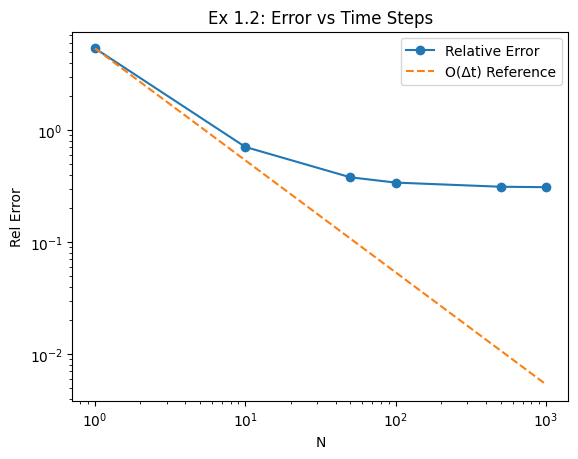

In [10]:
N_steps_list = [1, 10, 50, 100, 500, 1000]
errors_N = [abs(v_true - run_monte_carlo_implicit(lqr_sim, x0, n, 100000)) / abs(v_true) for n in N_steps_list]

plt.loglog(N_steps_list, errors_N, '-o', label='Relative Error')
plt.loglog(N_steps_list, [errors_N[0]/n for n in N_steps_list], '--', label='O(Δt) Reference')
plt.title("Ex 1.2: Error vs Time Steps")
plt.xlabel("N"); plt.ylabel("Rel Error"); plt.legend(); plt.show()

Iteration 1: Value Error = 17.4261, Action Error = 0.8831
Iteration 2: Value Error = 14.3910, Action Error = 0.5331
Iteration 3: Value Error = 11.5172, Action Error = 0.1786
Iteration 4: Value Error = 7.8929, Action Error = 0.4185
Iteration 5: Value Error = 7.9975, Action Error = 0.1347


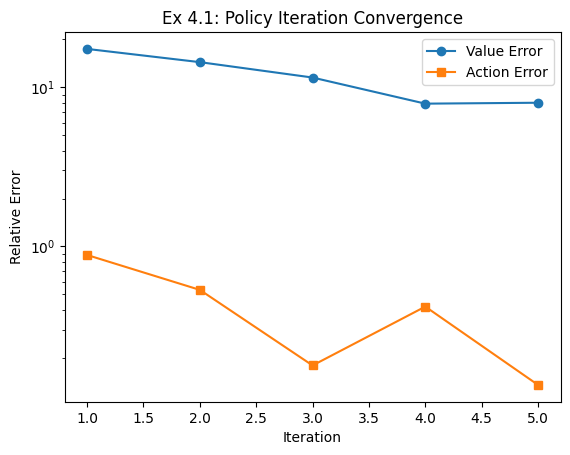

In [11]:
pia_results = run_policy_iteration(lqr_sim, x0)

plt.figure()
plt.plot(range(1, 6), pia_results["v_err"], '-o', label="Value Error")
plt.plot(range(1, 6), pia_results["a_err"], '-s', label="Action Error")
plt.yscale('log'); plt.xlabel("Iteration"); plt.ylabel("Relative Error")
plt.title("Ex 4.1: Policy Iteration Convergence"); plt.legend(); plt.show()


2: Supervised Learning...


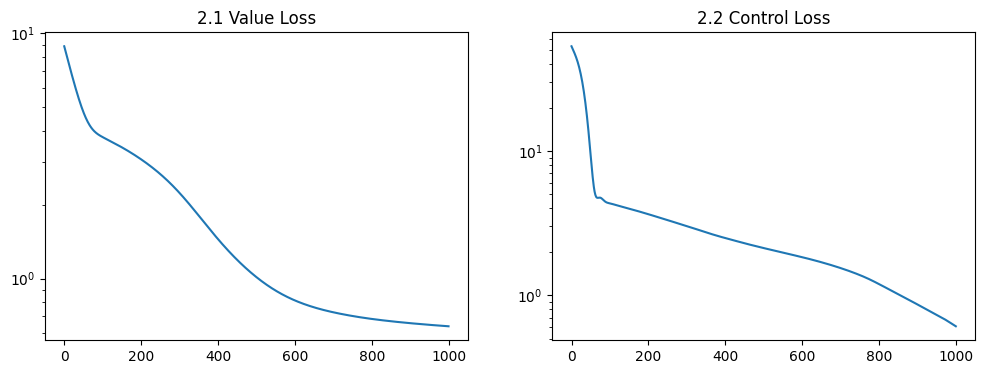

In [12]:
# -------- Exercise 2.1 & 2.2 -----------------
print("\n2: Supervised Learning...")
t_data = torch.rand(10000); x_data = torch.rand(10000, 1, 2) * 6 - 3
lqr_sim.solve_riccati(torch.linspace(0, T, 100))
v_target = lqr_sim.get_value(t_data, x_data)
a_target = lqr_sim.get_control(t_data, x_data)

loss_v = train_nn(Net_DGM(), t_data, x_data, v_target)
loss_a = train_nn(FFN(), t_data, x_data, a_target)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.plot(loss_v); plt.yscale('log'); plt.title("2.1 Value Loss")
plt.subplot(1, 2, 2); plt.plot(loss_a); plt.yscale('log'); plt.title("2.2 Control Loss")
plt.show()